In [ ]:
import os
import numpy as np
import torch
from matplotlib import pyplot as plt

from model.utils import new_rot_mat, extend_dim
from torch import Tensor




class GaussianList:
    def __init__(self, device: str | None=None, data=[]):
        self.gaussians = []
        self.device = device

        for pair in data:
            self.append(pair[0], pair[1], pair[2])


    def _gn2(self, x: Tensor, sig: Tensor, rot: Tensor, mu: Tensor=None):
        """
        xy: (N, 2)\n
        sig: (N, 2) | (2)\n
        rot: (N) | (1)\n
        mu: (N, 2) | (2)\n
        where N = N | N1, N2, ...\n
        """

        if mu is None:
            mu = torch.tensor([0.0, 0.0], device=self.device)

        rot_mat = new_rot_mat(extend_dim(rot, x.ndim - 1))
        sig_mat = extend_dim(torch.eye(2, device=self.device), x.ndim + 1).mul(extend_dim(sig, x.ndim, x.ndim + 1))

        L = rot_mat.matmul(sig_mat)
        big_sig = L.matmul(L.mT)
        d = x.sub(extend_dim(mu, x.ndim)).unsqueeze(-1)

        return d.mT.matmul(torch.linalg.solve(big_sig, d)).mul(-0.5).exp().squeeze(-1)


    def append(self, mu: Tensor, sig: Tensor, rot=0.0):
        if not isinstance(rot, Tensor):
            rot = torch.tensor(rot)

        self.gaussians.append((mu.to(device=self.device), sig.to(device=self.device), rot.to(device=self.device)))


    def pop(self, idx: int):
        return self.gaussians.pop(idx)


    def display_one(self, xy: Tensor, idx: int):
        g = self.gaussians[idx]
        return self._gn2(xy.to(self.device), g[1], g[2], g[0])


    def display(self, xy: Tensor):
        xy_prep = xy.to(self.device)
        return torch.stack([
            self._gn2(xy_prep, g[1], g[2], g[0])
            for g in self.gaussians
        ], -1).sum(-1)


def get_2d_grid(num, range1, range0=0):
    base = torch.linspace(range0, range1, num)
    x = base.repeat(num).reshape(-1, num)
    y = base.repeat_interleave(num).reshape(-1, num)

    return torch.stack((x, y), -1)


def plot_img_grid(img: torch.Tensor, name: str, cells=10, contours=True):
    fig = plt.figure()
    ax = plt.axes([0.1, 0.1, 0.9, 0.9])
    ax.set_xticks(np.linspace(0, img.shape[0], cells - 1))
    ax.set_yticks(np.linspace(0, img.shape[1], cells - 1))

    # below grid (1), above plot (0)
    cs = ax.contour(img.squeeze(), levels=torch.linspace(0, 1, 11), cmap="magma", zorder=.5)
    ax.grid(True)

    ax.imshow(img)
    fig.add_axes(ax)

    folder_path = os.path.join("results", "figures")
    os.makedirs(folder_path, exist_ok=True)
    fig.savefig(os.path.join(folder_path, f"intro_{name}.png"), bbox_inches="tight", pad_inches=0.2)


def construct_quick_gaussian(name, mu: tuple, sig: tuple, rot: float, pixels=400, cells=10):
    gauss = GaussianList()
    gauss.append(torch.tensor(mu), torch.tensor(sig), torch.tensor(rot))

    img = gauss.display(get_2d_grid(pixels, 1))

    plot_img_grid(img, name, cells)

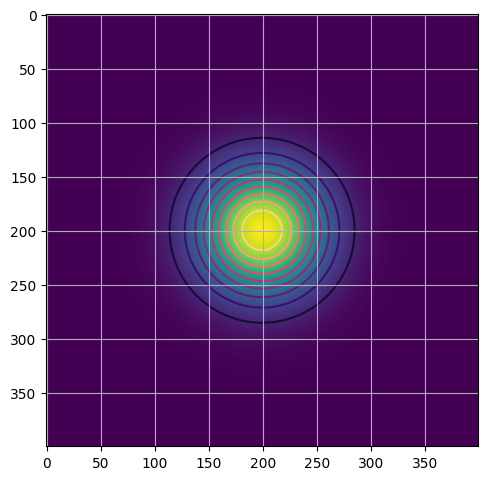

In [41]:
construct_quick_gaussian("base", [0.5, 0.5], [0.1, 0.1], 0)

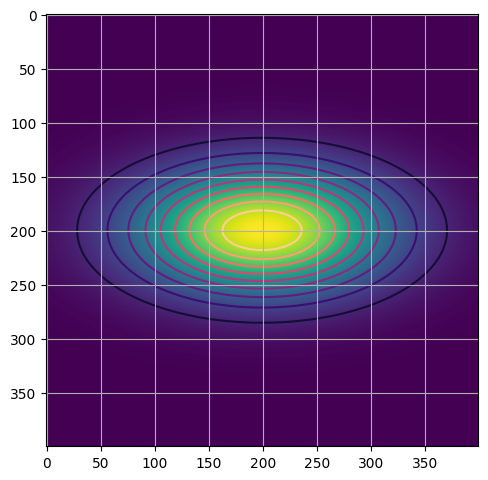

In [42]:
construct_quick_gaussian("scale_2x", [0.5, 0.5], [0.2, 0.1], 0)

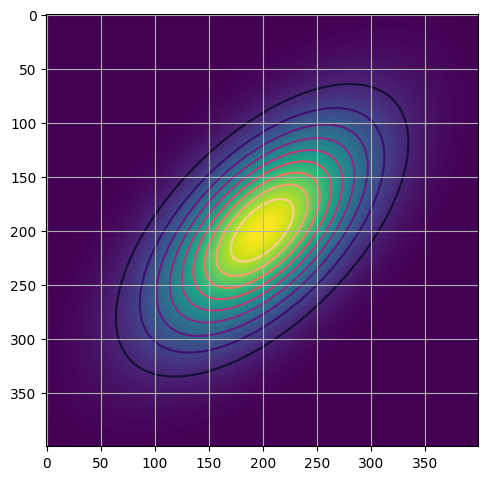

In [43]:
construct_quick_gaussian("rotate_45deg", [0.5, 0.5], [0.2, 0.1], torch.pi / 4)